In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [2]:
def torch_schatten_norm(A, p):
    # Compute singular values
    singular_values = torch.linalg.svdvals(A)
    
    if p == float('inf'):
        return torch.max(singular_values)
    else:
        return torch.linalg.vector_norm(singular_values, ord=p)
# Example usage:normal_tensor = torch.randn(3, 3)

In [ ]:
list_p = [1, 2, 3, 4, 5, 6, float('inf')]
for i in range(1):
    B = torch.randn(5000, 5000)
    for p in list_p:
        print("PyTorch Schatten: ", torch_schatten_norm(B, p), p)

In [3]:
import time
import numpy as np
from sklearn.utils.extmath import randomized_svd

# Conditional import for JAX (in case it's run in a CPU-only or non-JAX environment)
try:
    import jax
    import jax.numpy as jnp
    from jax import jit
    JAX_AVAILABLE = True
except ImportError:
    JAX_AVAILABLE = False

# -------------------------------------------------------------------------
# 1. METHOD: Baseline NumPy (Exact, Full SVD)
# -------------------------------------------------------------------------
def schatten_norm_numpy(A, p):
    """Computes exact Schatten p-norm using standard NumPy SVD."""
    s = np.linalg.svd(A, compute_uv=False)
    return np.linalg.norm(s, ord=p)

# -------------------------------------------------------------------------
# 2. METHOD: Safe Randomized SVD (Approximation for p close to 1)
# -------------------------------------------------------------------------
def schatten_norm_randomized(A, p, rank=250, n_iter=2):
    """
    Approximates Schatten p-norm using Randomized SVD.
    Optimized for 1 <= p < 6 by using higher n_iter and rank to capture the tail.
    """
    # Guardrail: rank cannot exceed matrix dimensions
    max_rank = min(A.shape)
    rank = min(rank, max_rank)
    
    # n_iter=5 forces deeper power iterations to stabilize small singular values
    _, s, _ = randomized_svd(A, n_components=rank, n_oversamples=100, n_iter=2, random_state=42)
    return np.linalg.norm(s, ord=p)

# -------------------------------------------------------------------------
# 3. METHOD: JAX JIT Compiled (Exact, Lightning Fast on GPU/Multi-core CPU)
# -------------------------------------------------------------------------
if JAX_AVAILABLE:
    @jit(static_argnums=1)
    def _jax_schatten_backend(A, p):
        s = jnp.linalg.svd(A, compute_uv=False)
        return jnp.linalg.norm(s, ord=p)

    def schatten_norm_jax(A, p):
        """Computes exact Schatten p-norm accelerated via JAX XLA compilation."""
        A_jax = jnp.array(A)
            # Since p is a standard Python float/int here, JAX can now cache the compilation properly
        return float(_jax_schatten_backend(A_jax, p))
else:
    def schatten_norm_jax(A, p):
        return "JAX not installed."

# -------------------------------------------------------------------------
# Execution & Benchmarking Simulation
# -------------------------------------------------------------------------
if __name__ == "__main__":
    # Define matrix size (e.g., 2000 x 2000)
    MATRIX_SIZE = 500
    P_VALUE = 1.2  # Crucial case: p is close to 1
    
    print(f"Generating a random {MATRIX_SIZE}x{MATRIX_SIZE} matrix...")
    # Generate a matrix with a decaying singular value spectrum (simulating real data)
    U, _ = np.linalg.qr(np.random.randn(MATRIX_SIZE, MATRIX_SIZE))
    V, _ = np.linalg.qr(np.random.randn(MATRIX_SIZE, MATRIX_SIZE))
    S = np.diag(1.0 / (np.arange(1, MATRIX_SIZE + 1) ** 0.5)) # Decaying tail
    A = U @ S @ V.T

    print(br"\n--- Starting Benchmark (Target p = {P_VALUE}) ---")

    # --- Test NumPy ---
    start = time.time()
    res_np = schatten_norm_numpy(A, p=P_VALUE)
    time_np = time.time() - start
    print(f"[NumPy Exact]      Norm: {res_np:.4f} | Time: {time_np:.4f} seconds")

    # --- Test Randomized SVD ---
    # We grab the top 200 singular values out of 2000 to check accuracy vs speed
    start = time.time()
    res_rand = schatten_norm_randomized(A, p=P_VALUE, rank=250, n_iter=2)
    time_rand = time.time() - start
    accuracy = (res_rand / res_np) * 100
    print(f"[Randomized SVD]   Norm: {res_rand:.4f} | Time: {time_rand:.4f} seconds ({accuracy:.2f}% accurate)")

    # --- Test JAX ---
    if JAX_AVAILABLE:
        # Warmup compilation run (JAX compiles on the first call, so we don't count it)
        _ = schatten_norm_jax(A, p=P_VALUE)
        
        start = time.time()
        res_jax = schatten_norm_jax(A, p=P_VALUE)
        time_jax = time.time() - start
        print(f"[JAX JIT Exact]    Norm: {res_jax:.4f} | Time: {time_jax:.4f} seconds")
    else:
        print("[JAX JIT Exact]    Skipped (JAX library not found)")

Generating a random 500x500 matrix...
b'\\n--- Starting Benchmark (Target p = {P_VALUE}) ---'
[NumPy Exact]      Norm: 16.1099 | Time: 0.0671 seconds
[Randomized SVD]   Norm: 12.5184 | Time: 0.1908 seconds (77.71% accurate)
[JAX JIT Exact]    Norm: 16.1099 | Time: 0.0385 seconds


In [4]:
def relu(A):
    m,n = np.shape(A)
    B = np.zeros((m,n))
    for i in range(m):
        for j in range(n):
            B[i,j] = max(0, A[i,j])
    return B
            

In [5]:
def loss(W, A, Y, n):
    return 1/(2*n) * (np.linalg.norm(W @ A - Y, 'fro')**2)  
def p1(p):
    if p == np.inf:
        return 1
    else: 
        return p/(p-1)
def p2(p):
    if p == 2:
        return np.inf
    if p == np.inf:
        return 2
    else:
        return 2*p/(p-2)

In [69]:
m, n = 100,1000
W_True = np.random.randn(m, n)
W_1 = np.random.randn(n, 50)
X = np.random.randn(50, m)
A = relu(W_1 @ X)
Y = W_True @ A
W0 = np.zeros((m, n))


In [6]:
try:
    import jax
    import jax.numpy as jnp
    from jax import jit
    JAX_AVAILABLE = True
except ImportError:
    JAX_AVAILABLE = False
def find_max(gradient, A, list_p):
    max_norm = 0
    p_max = 0
    for p in list_p:
        p_1 = p1(p)
        p_2 = p2(p)
        L_p = schatten_norm_jax(A, p=p_2)**2/n
        if schatten_norm_jax(gradient, p=p_1)**2/schatten_norm_jax(A, p=p_2)**2 > max_norm:
            max_norm = schatten_norm_jax(A, p=p_1)**2/schatten_norm_jax(A, p=p_2)**2
            p_max = p
    return p_max, p1(p_max), p2(p_max)

In [7]:
def ratio(gradient, A, p_1):
    U, S, Vt = np.linalg.svd(gradient, full_matrices=False)
    if p_1 == 1:
        return schatten_norm_jax(gradient, p=p_1)**(2*p_1)/ schatten_norm_jax(U @ Vt @ A, p=2)**2
    else:
        return schatten_norm_jax(gradient, p=p_1)**(2*p_1)/ schatten_norm_jax(U @ np.diag(S**(p_1-1)) @ Vt @ A, p=2)**2

In [8]:
def find_p(gradient, A, list_p):
    max_norm = -np.inf
    p_max = 0
    for p in list_p:
        p_1 = p1(p)
        p_2 = p2(p)
        U, S, Vt = np.linalg.svd(gradient, full_matrices=False)
        r = ratio(gradient, A, p_1)
        if r > max_norm:
            max_norm = r
            p_max = p
    return p_max, p1(p_max), p2(p_max)

In [9]:
def learning_rate(gradient, A, n, p):
    U, S, Vt = np.linalg.svd(gradient, full_matrices=False)
    p_1 = p1(p)
    if p_1 == 1:
        return n*schatten_norm_jax(gradient, p=p_1)/np.linalg.norm(U @ Vt @ A, 'fro')**2
    else:
        return n*schatten_norm_jax(gradient, p=p_1)**(p_1)/ (np.linalg.norm(U @ np.diag(S**(p_1-1)) @ Vt @ A, 'fro')**2)

In [10]:
def tuned_norm_optimizer(W0, A, Y, n, W_True, nb_iter, list_p):
    training_loss = [loss(W0, A, Y, n)]
    W = W0
    for i in range(1, nb_iter):
        gradient = 1/n * (W @ A - Y) @ A.T
        p, p_dual, p_2dual = find_p(gradient,A, list_p)
        U, S, Vt = np.linalg.svd(gradient, full_matrices=False)
        if p_dual == 1:
            U_polar = U @ Vt
        else:
            U_polar = U @ np.diag(S**(p_dual-1)) @ Vt
        W = W - learning_rate(gradient, A, n, p) * U_polar
        training_loss.append(loss(W, A, Y, n))
        
    return training_loss

In [11]:
def tuned_norm(W0, A, Y, n, W_True, nb_iter, list_p):
    L_op = (np.linalg.norm(A, 'fro')**2)/n
    training_loss = [loss(W0, A, Y, n)]
    W = W0
    for i in range(1, nb_iter):
        gradient = 1/n * (W @ A - Y) @ A.T
        p, p_dual, p_2dual = find_max(gradient,A, list_p)
        U, S, Vt = np.linalg.svd(gradient, full_matrices=False)
        if p_dual == 1:
            U_polar = U @ Vt
        else:
            U_polar = U @ np.diag(S**(p_dual-1)) @ Vt
        W = W - n/ (schatten_norm_jax(A, p_2dual)**2 * schatten_norm_jax(gradient, p_dual)**(p_dual - 2)) * U_polar
        training_loss.append(loss(W, A, Y, n))
        
    return training_loss

In [12]:
def SpecGD(W0, A, Y, n, W_True, nb_iter):
    L_op = (np.linalg.norm(A, 'fro')**2)/n
    training_loss = [loss(W0, A, Y, n)]
    nr = []
    W = W0
    for i in range(1, nb_iter):
        gradient = 1/n * (W @ A - Y) @ A.T
        nr.append(np.linalg.norm(gradient, 'nuc')**2 / np.linalg.norm(gradient, 'fro')**2) 
        U, S, Vt = np.linalg.svd(gradient, full_matrices=False)
        U_polar = U @ Vt
        W = W - np.linalg.norm(gradient, 'nuc') / L_op * U_polar
        training_loss.append(loss(W, A, Y, n))
        
    return training_loss, nr

In [13]:
def GD(W0, A, Y, n, W_True, nb_iter):
    L_f = (np.linalg.norm(A, 2)**2)/n
    training_loss = [loss(W0, A, Y, n)]
    nr = []
    W = W0
    for i in range(1, nb_iter):
        gradient = 1/n * (W @ A - Y) @ A.T
        nr.append(np.linalg.norm(gradient, 'nuc')**2 / np.linalg.norm(gradient, 'fro')**2) 
        W = W - gradient / L_f
        training_loss.append(loss(W, A, Y,n))
        
    return training_loss, nr

In [72]:
relu_loss_GD, swiglu_nr_GD = GD(W0, A, Y, 1000, W_True, 1000)
relu_loss_SpecGD, swiglu_nr_SpecGD = SpecGD(W0, A, Y, 1000, W_True, 1000)
relu_loss_tuned_optimizer = tuned_norm_optimizer(W0, A, Y, n, W_True, 1000, list_p)
relu_GD_optimal = GD_optimal(W0, A, Y, n, W_True, 1000)
relu_specGD_optimal = SpecGD_optimal(W0, A, Y, n, W_True, 1000)



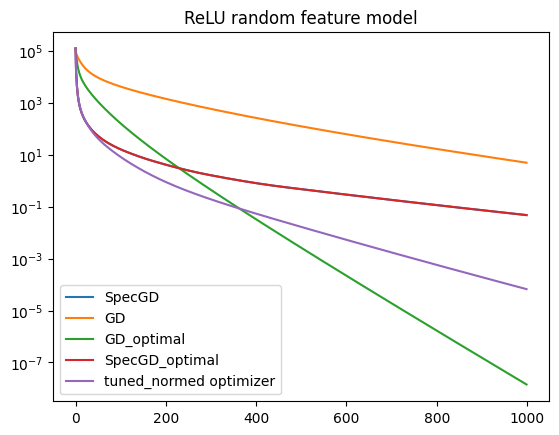

In [73]:
plt.plot(relu_loss_SpecGD, label="SpecGD")
plt.plot(relu_loss_GD, label="GD")
plt.plot(relu_GD_optimal, label="GD_optimal")
plt.plot(relu_specGD_optimal, label="SpecGD_optimal")
plt.plot(relu_loss_tuned_optimizer, label="tuned_normed optimizer")
plt.yscale('log')
plt.title("ReLU random feature model")
plt.legend()

In [14]:
def swiglu(A,B):
    A = A/(1 + np.exp(-A))
    return A * B

In [15]:
m, n = 100, 1000
W_True = np.random.randn(m, n)
W_1 = np.random.randn(n, 50)
W_2 = np.random.randn(n, 50)
X = np.random.randn(50, m)
A = swiglu(W_1 @ X, W_2 @ X)
Y = W_True @ A
W0 = np.zeros((m, n))
list_p = np.linspace(2, 20, 50)
list_p[-1] = np.inf

In [31]:
def GD_optimal(W0, A, Y, n, W_True, nb_iter):
    training_loss = [loss(W0, A, Y, n)]
    W = W0
    for i in range(1, nb_iter):
        gradient = 1/n * (W @ A - Y) @ A.T
        W = W - gradient * learning_rate(gradient, A, n, 2)
        training_loss.append(loss(W, A, Y,n))
        
    return training_loss

In [53]:
def SpecGD_optimal(W0, A, Y, n, W_True, nb_iter):
    training_loss = [loss(W0, A, Y, n)]
    W = W0
    for i in range(1, nb_iter):
        gradient = 1/n * (W @ A - Y) @ A.T
        U, S, Vt = np.linalg.svd(gradient, full_matrices=False)
        U_polar = U @ Vt
        W = W - learning_rate(gradient, A, n, np.inf) * U_polar
        training_loss.append(loss(W, A, Y, n))
        
    return training_loss

In [ ]:
def tuned_norm_optimizer(W0, A, Y, n, W_True, nb_iter, list_p):
    training_loss = [loss(W0, A, Y, n)]
    W = W0
    list_p = np.linspace(0,3, 50)
    list_p[-1] = np.inf
    for i in range(1, nb_iter):
        gradient = 1/n * (W @ A - Y) @ A.T
        p, p_dual, p_2dual = find_p(gradient,A, list_p)
        U, S, Vt = np.linalg.svd(gradient, full_matrices=False)
        if p_dual == 1:
            U_polar = U @ Vt
        else:
            U_polar = U @ np.diag(S**(p_dual-1)) @ Vt
        W = W - learning_rate(gradient, A, n, p) * U_polar
        training_loss.append(loss(W, A, Y, n))
        
    return training_loss

In [46]:
switglu_loss_GD, swiglu_nr_GD = GD(W0, A, Y, 1000, W_True, 400)
switglu_loss_SpecGD, swiglu_nr_SpecGD = SpecGD(W0, A, Y, 1000, W_True, 400)
switglu_loss_tuned_normed = tuned_norm(W0, A, Y, n, W_True, 400, list_p)
switglu_loss_tuned_optimizer = tuned_norm_optimizer(W0, A, Y, n, W_True, 400, list_p)
switglu_GD_optimal = GD_optimal(W0, A, Y, n, W_True, 400)
switglu_specGD_optimal = SpecGD_optimal(W0, A, Y, n, W_True, 400)

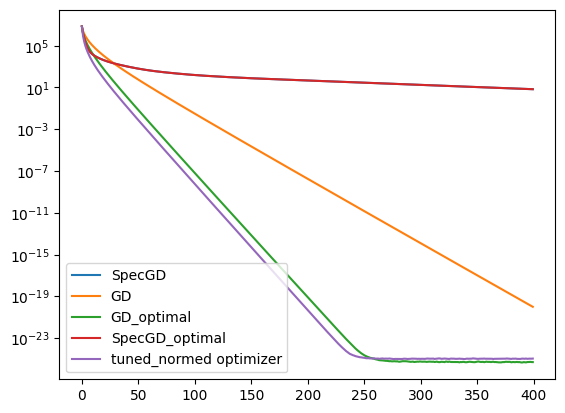

In [64]:
plt.plot(switglu_loss_SpecGD, label="SpecGD")
plt.plot(switglu_loss_GD, label="GD")
plt.plot(switglu_GD_optimal, label="GD_optimal")
plt.plot(switglu_specGD_optimal, label="SpecGD_optimal")
plt.plot(switglu_loss_tuned_optimizer, label="tuned_normed optimizer")
plt.yscale('log')
plt.legend()